<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

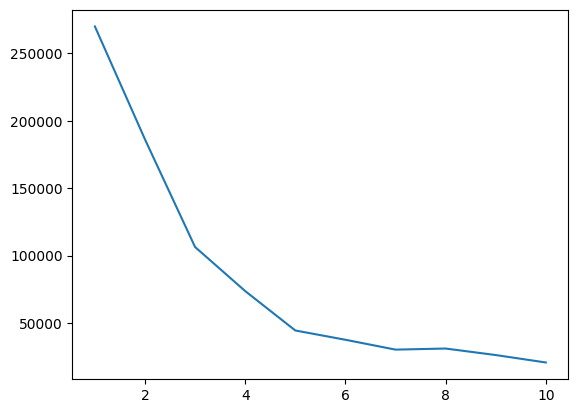

In [ ]:
# clustering - grouping unlabelled data
# supervised learning - regr., class.
# k means clustering
# centre of mass / gravity for each of clusters
# move centroids to those positions
# elbow method - wcss within cluster sum of squares

# random initialization trap -> k means ++
# just select first centroid at random
# compute distance D and use weighted random selection by D^2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('customers.csv')
X = data.iloc[:, [3, 4]].values

from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i)
    # n_clusters def 8
    # init def k-means++, random
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    # Sum of squared distances of samples to their closest cluster center,
    # weighted by the sample weights if provided.

plt.plot(range(1, 11), wcss)

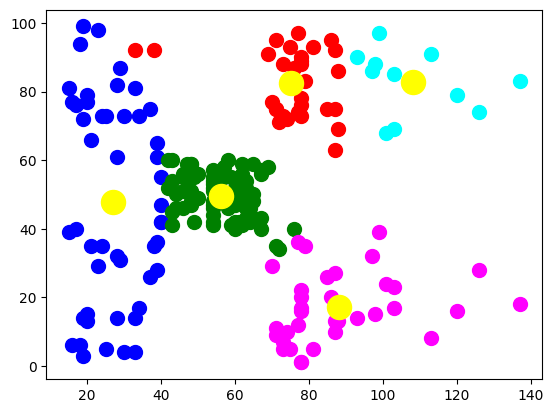

In [ ]:
kmeans = KMeans(n_clusters = 5)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow')

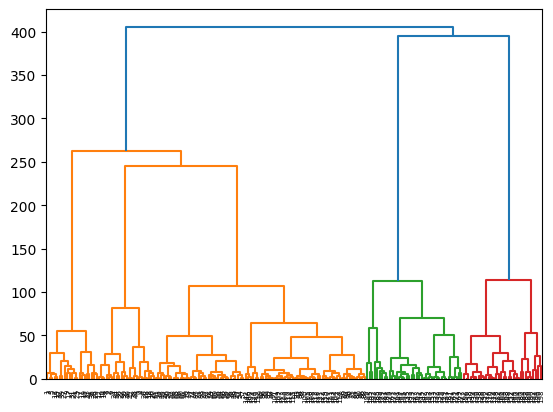

In [ ]:
# hierarchical clustering: agglomerative (bottom up) & divisive
# make each point a single point cluster
# take 2 closest points make them 1 cluster
# take 2 closest clusters make them 1 cluster
# (repeat until there is 1 cluster)

# dendrogram - memory of hc
# look horizontal levels, set thresholds for dissimilarity,
# largest vertical distance, set threshold horizontal line to cross it
# without touching horizontal lines
# choose cluster numbers

import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
# The linkage matrix encoding the hierarchical clustering to render as a dendrogram
# linkage: Perform hierarchical/agglomerative clustering.
# method: single, complete, average, weighted, centroid, median, ward
# method=’ward’ uses the Ward variance minimization algorithm.

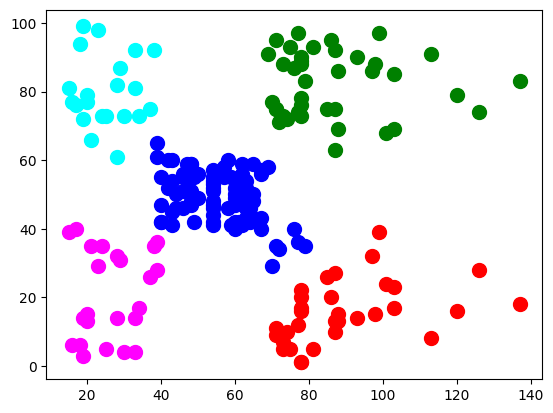

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5)
# Recursively merges pair of clusters of sample data; uses linkage distance.
# n_clusters def. 2
# metric='euclidean', Metric used to compute the linkage.
# linkage='ward' determines which distance to use between sets of observation.
# The algorithm will merge the pairs of cluster that minimize this criterion.
# ‘complete’, ‘average’, ‘single’
# ‘ward’ minimizes the variance of the clusters being merged.
y_hc = hc.fit_predict(X)

plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta')